In [2]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

df = pd.read_csv("D:\DA- Project 2\Data\daily_energy_met_MU.csv")
df_clean = df.groupby('Date', as_index=False).mean(numeric_only=True)
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

df_national = df_clean[['Date', 'Total']].copy().sort_values('Date').reset_index(drop=True)

print(df_national)

           Date   Total
0    2013-01-01  2629.8
1    2013-01-02  2693.9
2    2013-01-03  2753.0
3    2013-01-04  2760.2
4    2013-01-05  2650.8
...         ...     ...
3895 2024-04-24  4879.4
3896 2024-04-25  4990.9
3897 2024-04-26  4995.6
3898 2024-04-27  5015.9
3899 2024-04-28  4873.5

[3900 rows x 2 columns]


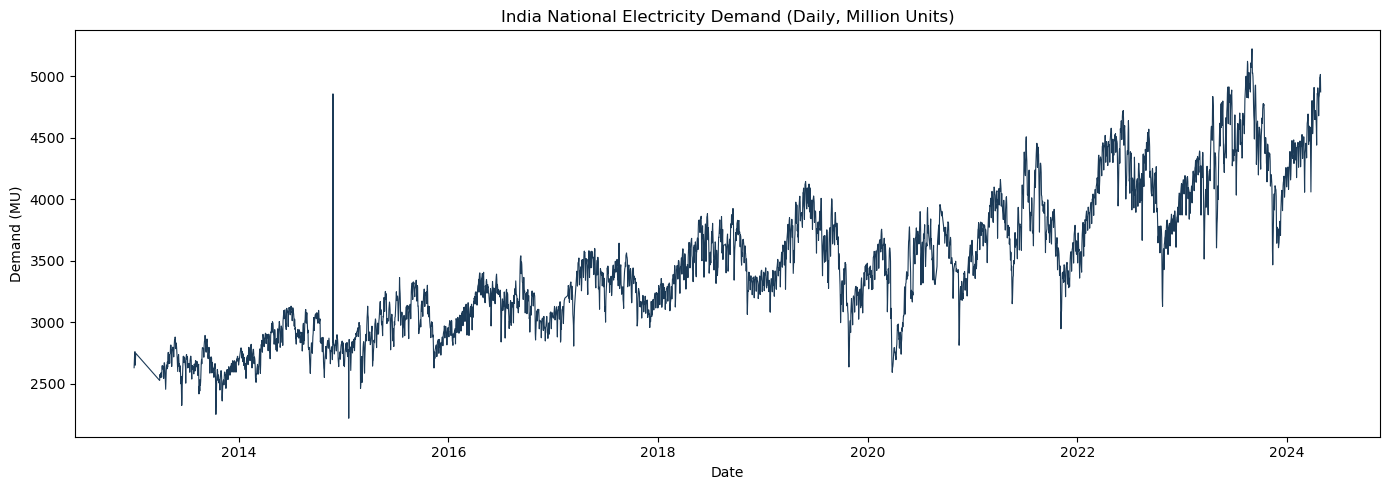

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
plt.plot(df_national['Date'], df_national['Total'], linewidth=0.8, color='#1B3A57')
plt.title("India National Electricity Demand (Daily, Million Units)")
plt.xlabel("Date"); plt.ylabel("Demand (MU)")
plt.tight_layout()
plt.savefig("01_full_timeseries.png", dpi=200)
plt.show()

In [5]:
spike_idx = df_national[df_national['Date'] == '2014-11-25'].index[0]
print(df_national.iloc[spike_idx-3 : spike_idx+4][['Date','Total']])

          Date   Total
588 2014-11-22  2797.1
589 2014-11-23  2695.3
590 2014-11-24  2788.4
591 2014-11-25  4857.7
592 2014-11-26  2833.3
593 2014-11-27  2832.0
594 2014-11-28  2813.9


In [6]:
df_national['rolling_mean'] = df_national['Total'].rolling(window=30, center=True).mean()
df_national['rolling_std'] = df_national['Total'].rolling(window=30, center=True).std()
df_national['z_score'] = (df_national['Total'] - df_national['rolling_mean']) / df_national['rolling_std']

real_outliers = df_national[df_national['z_score'].abs() > 3]
print(real_outliers[['Date', 'Total', 'z_score']])

           Date   Total   z_score
192  2013-10-13  2250.3 -3.361255
591  2014-11-25  4857.7  5.249074
645  2015-01-19  2218.7 -4.544316
1123 2016-05-29  2969.4 -3.363181
3280 2022-08-15  3666.1 -3.089527


In [7]:
outlier_dates = real_outliers['Date']
df_national = df_national[~df_national['Date'].isin(outlier_dates)].reset_index(drop=True)
print(df_national.shape)

(3895, 5)


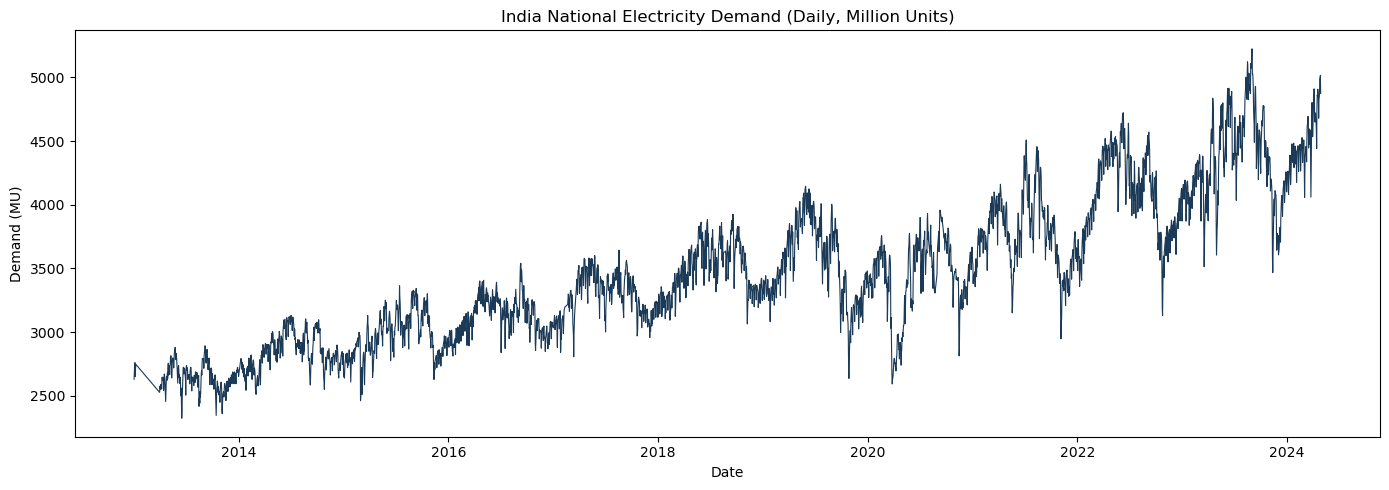

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
plt.plot(df_national['Date'], df_national['Total'], linewidth=0.8, color='#1B3A57')
plt.title("India National Electricity Demand (Daily, Million Units)")
plt.xlabel("Date"); plt.ylabel("Demand (MU)")
plt.tight_layout()
plt.savefig("01_full_timeseries.png", dpi=200)
plt.show()

In [9]:
df_national = df_national.drop(columns=['rolling_mean', 'rolling_std', 'z_score'])

print("df_clean:", df_clean.shape)
print("df_national:", df_national.shape)

df_clean: (3900, 40)
df_national: (3895, 2)


In [10]:
import statsmodels.api as sm

In [11]:
df_reg = df_national.copy()
df_reg['time_trend'] = (df_reg['Date'] - df_reg['Date'].min()).dt.days
X = sm.add_constant(df_reg['time_trend'])
y = df_reg['Total']

model = sm.OLS(y , X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Total   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                 1.338e+04
Date:                Fri, 14 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:25:55   Log-Likelihood:                -27347.
No. Observations:                3895   AIC:                         5.470e+04
Df Residuals:                    3893   BIC:                         5.471e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2566.4750      8.940    287.083      0.0

In [12]:
print(df_clean.shape)
print(df_clean.columns.tolist()[:6])

(3900, 40)
['Date', 'Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar']


In [13]:
states_of_interest = ['Maharashtra', 'Uttar Pradesh']

df_states = df_clean[['Date'] + states_of_interest].copy()
df_long = df_states.melt(id_vars = 'Date', var_name = 'State', value_name= 'Demand')
print(df_long.shape)
print(df_long.head())
print(df_long.tail())

(7800, 3)
        Date        State  Demand
0 2013-01-01  Maharashtra   353.1
1 2013-01-02  Maharashtra   361.7
2 2013-01-03  Maharashtra   357.7
3 2013-01-04  Maharashtra   365.0
4 2013-01-05  Maharashtra   356.7
           Date          State  Demand
7795 2024-04-24  Uttar Pradesh   461.9
7796 2024-04-25  Uttar Pradesh   475.8
7797 2024-04-26  Uttar Pradesh   477.3
7798 2024-04-27  Uttar Pradesh   496.8
7799 2024-04-28  Uttar Pradesh   492.2


In [14]:
df_long['Date'] = pd.to_datetime(df_long['Date'])

study_window = df_long[
    (df_long['Date'] >= '2020-04-15') & (df_long['Date'] <= '2020-07-31')
].copy()
print(study_window.shape)
print(study_window['Date'].min(), study_window['Date'].max())

(206, 3)
2020-04-15 00:00:00 2020-07-31 00:00:00


In [15]:
study_window['Treated'] = (study_window['State']== 'Maharashtra').astype(int)
study_window['Post'] = (study_window['Date'] >= '2020-06-01').astype(int)
study_window['Treated_Post'] = study_window['Treated'] * study_window['Post']

print(study_window[['State', 'Date', 'Treated', 'Post', 'Treated_Post']].sample(6))
#Basically we assigned the treatment state (Maharashtra) and the control state(UP) by converting the boolean true and false using astype(int)
# Maharashtra = True, 1 
#also we did the same while splitting the data based on dates. 
# after 1st june when every state was not on the same page as the national guidelines is assigned as True (1). 

              State       Date  Treated  Post  Treated_Post
2495    Maharashtra 2020-04-17        1     0             0
6454  Uttar Pradesh 2020-06-17        0     1             0
2572    Maharashtra 2020-07-08        1     1             1
2496    Maharashtra 2020-04-18        1     0             0
6413  Uttar Pradesh 2020-05-06        0     0             0
6462  Uttar Pradesh 2020-06-26        0     1             0


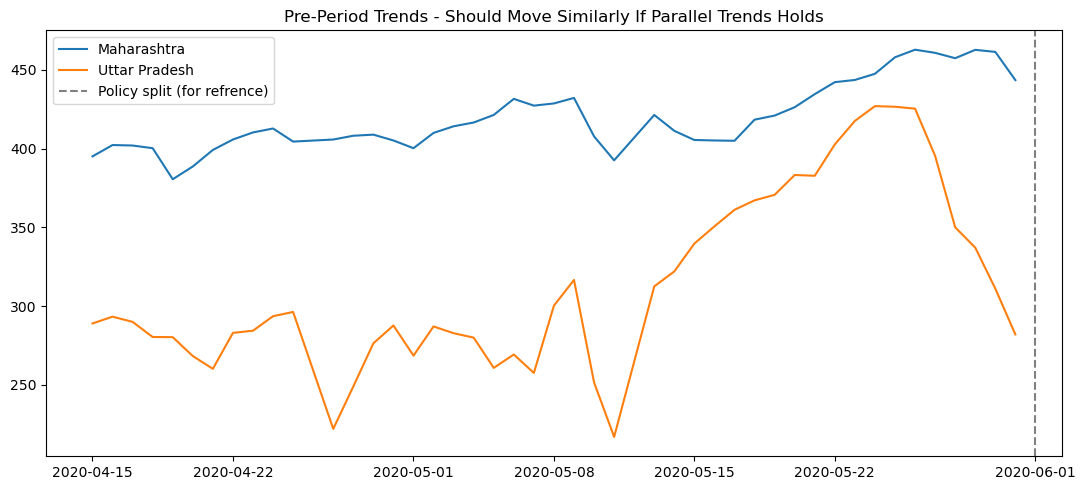

In [16]:
# checking parallel trends 
# The Visual check
import matplotlib.pyplot as plt

pre_period = study_window[study_window['Post'] == 0]

fig, ax = plt.subplots(figsize = (11,5))
for state, grp in pre_period.groupby('State') :     # Used to create a dataframe based on states so as to easily plot the line chart for each states separatley on the single canvas.
    ax.plot(grp['Date'], grp['Demand'], label=state)
ax.axvline(pd.Timestamp('2020-06-01'), color = 'gray', linestyle= '--', label= 'Policy split (for refrence)')
ax.legend()
ax.set_title("Pre-Period Trends - Should Move Similarly If Parallel Trends Holds")
plt.tight_layout()
plt.savefig("01_parallel_trends_check.png", dpi=200)
plt.show()    


In [17]:
check = study_window[(study_window['Date'] >= '2020-04-22') & (study_window['Date'] <= '2020-05-01')]
print(check)

           Date          State  Demand  Treated  Post  Treated_Post
2500 2020-04-22    Maharashtra   405.7        1     0             0
2501 2020-04-23    Maharashtra   410.2        1     0             0
2502 2020-04-24    Maharashtra   412.7        1     0             0
2503 2020-04-25    Maharashtra   404.4        1     0             0
2504 2020-04-27    Maharashtra   405.7        1     0             0
2505 2020-04-28    Maharashtra   408.1        1     0             0
2506 2020-04-29    Maharashtra   408.8        1     0             0
2507 2020-04-30    Maharashtra   405.1        1     0             0
2508 2020-05-01    Maharashtra   400.2        1     0             0
6400 2020-04-22  Uttar Pradesh   283.0        0     0             0
6401 2020-04-23  Uttar Pradesh   284.4        0     0             0
6402 2020-04-24  Uttar Pradesh   293.6        0     0             0
6403 2020-04-25  Uttar Pradesh   296.3        0     0             0
6404 2020-04-27  Uttar Pradesh   222.1        0 

In [18]:
import statsmodels.formula.api as smf

pre_period = pre_period.copy()
pre_period['time_trend'] = (pre_period['Date'] - pre_period['Date'].min()).dt.days

pretrend_model = smf.ols('Demand ~ Treated * time_trend' , data = pre_period).fit()
print(pretrend_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Demand   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     116.5
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           3.45e-30
Time:                        14:25:56   Log-Likelihood:                -434.22
No. Observations:                  90   AIC:                             876.4
Df Residuals:                      86   BIC:                             886.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            250.1943      9

In [ ]:
# Due to P< 0.003 our null Hypothesis gets rejected (that before policy change the countries demands were statistically significant already and moving differently ).
# so Now we are gonna perform another DiD with new control state which is- Gujarat. 

In [20]:
states_of_interest_1 = ['Maharashtra', 'Gujarat']

df_states_1 = df_clean[['Date'] + states_of_interest_1].copy()
df_long_1 = df_states_1.melt(id_vars = 'Date', var_name = 'State', value_name = 'Demand')
print(df_long_1.shape)
print(df_long_1.head())
print(df_long_1.tail())

(7800, 3)
        Date        State  Demand
0 2013-01-01  Maharashtra   353.1
1 2013-01-02  Maharashtra   361.7
2 2013-01-03  Maharashtra   357.7
3 2013-01-04  Maharashtra   365.0
4 2013-01-05  Maharashtra   356.7
           Date    State  Demand
7795 2024-04-24  Gujarat   473.0
7796 2024-04-25  Gujarat   485.0
7797 2024-04-26  Gujarat   483.2
7798 2024-04-27  Gujarat   481.8
7799 2024-04-28  Gujarat   457.8


In [21]:
df_long_1['Date'] = pd.to_datetime(df_long_1['Date'])

study_window_1 = df_long_1[
    (df_long_1['Date'] >= '2020-04-15') & (df_long_1['Date'] <= '2020-07-31')
].copy()

print(study_window_1.shape)
print(study_window_1['Date'].min(), study_window_1['Date'].max())

(206, 3)
2020-04-15 00:00:00 2020-07-31 00:00:00


In [22]:
study_window_1['Treated'] = (study_window_1['State'] == 'Maharashtra').astype(int)
study_window_1['Post'] = (study_window_1['Date'] >= '2020-06-01').astype(int)
study_window_1['Treated_Post'] = study_window_1['Treated'] * study_window_1['Post']

print(study_window_1[['Date', 'State', 'Treated', 'Post', 'Treated_Post']].sample(6))

# Basically we assigned True to the treatment state (Maharashtra) and False to the control state(Gujarat) by using astype(int).
# Maharashtra = True, 1     guj = False, 0.
# also we did the same while splitting the data based on dates. 
# after 1st june when every state was not on the same page as the national guidelines is assigned as True (1).


           Date        State  Treated  Post  Treated_Post
2511 2020-05-04  Maharashtra        1     0             0
2527 2020-05-21  Maharashtra        1     0             0
2573 2020-07-09  Maharashtra        1     1             1
6448 2020-06-11      Gujarat        0     1             0
6424 2020-05-18      Gujarat        0     0             0
6457 2020-06-20      Gujarat        0     1             0


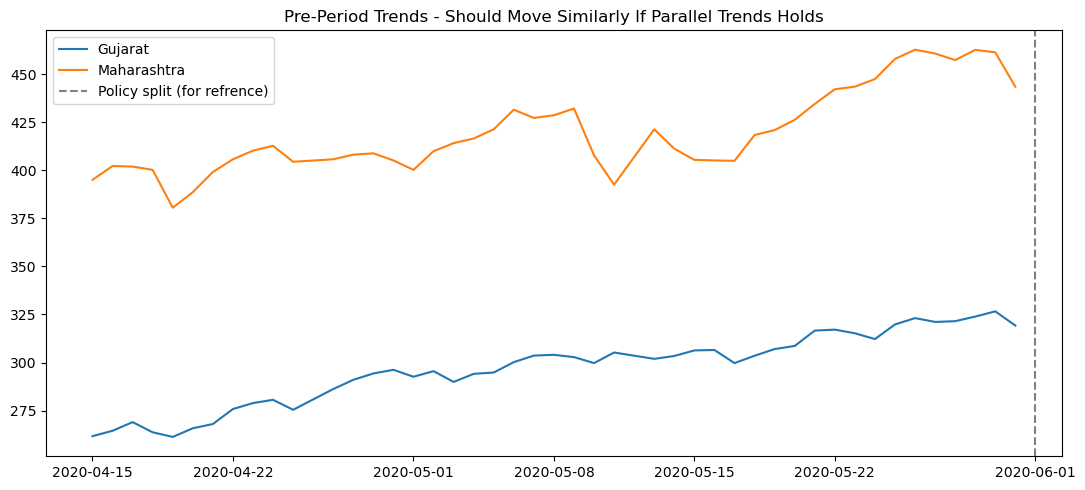

In [23]:
import matplotlib.pyplot as plt

pre_period_1 = study_window_1[study_window_1['Post'] == 0]

fig, ax = plt.subplots(figsize = (11,5))
for state, grp in pre_period_1.groupby('State') :     # Used to create mini dataframes as grp, sorted based on states so as to easily plot the line chart for each states separatley on the single canvas.
    ax.plot(grp['Date'], grp['Demand'], label=state)
ax.axvline(pd.Timestamp('2020-06-01'), color = 'gray', linestyle= '--', label= 'Policy split (for refrence)')
ax.legend()
ax.set_title("Pre-Period Trends - Should Move Similarly If Parallel Trends Holds")
plt.tight_layout()
plt.savefig("02_parallel_trends_check.png", dpi=200)
plt.show()    

In [24]:
import statsmodels.formula.api as smf
pre_period_1 = pre_period_1.copy()
pre_period_1['time_trend'] = (pre_period_1['Date'] - pre_period_1['Date'].min()).dt.days
pretrend_model_1 = smf.ols('Demand ~ Treated * time_trend', data=pre_period_1).fit()
print(pretrend_model_1.summary())
# demand = b0 + b1(treated) + b2(time trend) + b3(treated * time trend)
# note-  "time trend- here is the continous value" and treated is the binary switch (0 and 1 - false and true).

                            OLS Regression Results                            
Dep. Variable:                 Demand   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     1321.
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           8.72e-72
Time:                        14:25:57   Log-Likelihood:                -329.59
No. Observations:                  90   AIC:                             667.2
Df Residuals:                      86   BIC:                             677.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            266.7867      2

In [25]:
# DiD Regression for the Maharashtra-Gujarat
did_model_1 = smf.ols('Demand ~ Treated + Post + Treated_Post', data=study_window_1).fit()
print(did_model_1.summary())
# demand = b0 + b1(treated) + b2(post) + b3(treated * post)
# note - treated and post both are binary switches (0 and 1- false and true)

                            OLS Regression Results                            
Dep. Variable:                 Demand   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     392.8
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           5.32e-84
Time:                        14:25:57   Log-Likelihood:                -920.28
No. Observations:                 206   AIC:                             1849.
Df Residuals:                     202   BIC:                             1862.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      297.0667      3.174     93.601   

In [ ]:
placebo_window = df_long_1[
    (df_long_1['Date'] >= '2020-04-01') & (df_long_1['Date'] <= '2020-05-15')
].copy()

placebo_window['Treated'] = (placebo_window['State'] == 'Maharashtra').astype(int)
placebo_window['Post'] = (placebo_window['Date'] >= '2020-05-01').astype(int)
placebo_window['Treated_Post'] = placebo_window['Treated'] * placebo_window['Post']

placebo_model = smf.ols('Demand ~ Treated + Post + Treated_Post', data=placebo_window).fit()
print(placebo_model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Demand   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     486.1
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           4.22e-52
Time:                        14:43:24   Log-Likelihood:                -357.90
No. Observations:                  86   AIC:                             723.8
Df Residuals:                      82   BIC:                             733.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      258.8379      2.953     87.649   

In [ ]:
# A placebo test at a fake May 1 cutoff found a smaller but still statistically significant effect (-16.36, p=0.028, ~4.2%) coz of the dip in MHA around mid may whereas GUJ has no such dip.
# So now we are gonna perfom one more placebo test with a different window where no such significant dip happened.

In [30]:
placebo_window_A = df_long_1[
    (df_long_1['Date'] >= '2020-04-01') & (df_long_1['Date'] <= '2020-04-30')
].copy()

placebo_window_A['Treated'] = (placebo_window_A['State'] == 'Maharashtra').astype(int)
placebo_window_A['Post'] = (placebo_window_A['Date'] >= '2020-04-15').astype(int)
placebo_window_A['Treated_Post'] = placebo_window_A['Treated'] * placebo_window_A['Post']

placebo_model_A = smf.ols('Demand ~ Treated + Post + Treated_Post', data=placebo_window_A).fit()
print(placebo_model_A.summary())


                            OLS Regression Results                            
Dep. Variable:                 Demand   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     749.1
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           5.90e-44
Time:                        14:52:39   Log-Likelihood:                -218.73
No. Observations:                  58   AIC:                             445.5
Df Residuals:                      54   BIC:                             453.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      240.9929      2.911     82.796   

In [ ]:
# A placebo test at a fake 15 april cutoff found a smaller but still statistically significant effect (-12.59, p=0.032, ~3.3%).
# [percentage = DiD(b3) / predicted average(of baseline demand of treatment grp)] * 100

In [34]:
export_df = study_window_1[['Date', 'State', 'Demand', 'Treated', 'Post']]
export_df.to_csv("Treatment-control_rec.csv", index= False)